<a href="https://colab.research.google.com/github/zlwym/Assignment03/blob/main/iat461_a3_zoemann_301452821.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Imports**

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


# **Load & Inspect Data**

In [ ]:
gdf = gpd.read_file("business-licences.geojson")

gdf.head()

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,province,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geometry
0,25,4637506,25-129785,00,(Anie Philip),None,Inactive,2024-11-26 05:02:01+00:00,2025-12-31,Long-term Rental,...,BC,CA,V5R 3T5,Renfrew-Collingwood,0.0,94.0,2026-07-01 02:32:20-07:00,None,None,None
1,25,4637507,25-129786,00,(Tony Haughian),None,Issued,2024-11-18 17:52:13+00:00,2025-12-31,Long-term Rental,...,BC,CA,V5T2N4,Mount Pleasant,0.0,226.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.088156984446, 'lat': 49.257735557...",POINT (-123.08816 49.25774)
2,25,4637508,25-129787,00,(Tony Haughian),None,Issued,2024-11-18 17:52:11+00:00,2025-12-31,Long-term Rental,...,BC,CA,None,Mount Pleasant,0.0,275.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.08956400354, 'lat': 49.2580534457...",POINT (-123.08956 49.25805)
3,25,4637511,25-129790,00,Simone Deborah Avram (Simone Avram),None,Issued,2025-01-13 23:28:19+00:00,2025-12-31,Long-term Rental,...,BC,CA,V5V 2C6,Riley Park,0.0,188.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.096461841129, 'lat': 49.248896343...",POINT (-123.09646 49.2489)
4,25,4637516,25-129795,00,(William Squibb),None,Issued,2025-02-10 02:52:10+00:00,2025-12-31,Long-term Rental,...,BC,CA,V5T 3Z3,Grandview-Woodland,0.0,437.0,2026-07-01 02:32:20-07:00,None,"{'lon': -123.066152409923, 'lat': 49.275460757...",POINT (-123.06615 49.27546)


In [ ]:
print("Rows     Columns")
gdf.shape

Rows     Columns


(204107, 26)

In [ ]:
gdf.columns

Index(['folderyear', 'licencersn', 'licencenumber', 'licencerevisionnumber',
       'businessname', 'businesstradename', 'status', 'issueddate',
       'expireddate', 'businesstype', 'businesssubtype', 'unit', 'unittype',
       'house', 'street', 'city', 'province', 'country', 'postalcode',
       'localarea', 'numberofemployees', 'feepaid', 'extractdate', 'geom',
       'geo_point_2d', 'geometry'],
      dtype='object')

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 204107 entries, 0 to 204106
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype                    
---  ------                 --------------   -----                    
 0   folderyear             204107 non-null  object                   
 1   licencersn             204107 non-null  object                   
 2   licencenumber          204107 non-null  object                   
 3   licencerevisionnumber  204107 non-null  object                   
 4   businessname           190635 non-null  object                   
 5   businesstradename      77307 non-null   object                   
 6   status                 204107 non-null  object                   
 7   issueddate             175296 non-null  datetime64[ms, UTC]      
 8   expireddate            175320 non-null  datetime64[ms]           
 9   businesstype           204107 non-null  object                   
 10  businesssubtype        2

In [ ]:
gdf.describe(include="all")

,folderyear,licencersn,licencenumber,licencerevisionnumber,businessname,businesstradename,status,issueddate,expireddate,businesstype,...,province,country,postalcode,localarea,numberofemployees,feepaid,extractdate,geom,geo_point_2d,geometry
count,204107,204107,204107,204107,190635,77307,204107,175296,175320,204107,...,204027,159233,108966,201393,204107.000000,128649.000000,204107,0,102566,102566
unique,3,204100,198523,7,61773,24269,5,NaN,NaN,94,...,48,1,6046,24,NaN,NaN,NaN,0,8881,8881
top,26,4983726,26-110595,00,Parking Corporation of Vancouver,Fasken Martineau DuMoulin LLP,Issued,NaN,NaN,Long-term Rental,...,BC,CA,V5Z 4C2,Downtown,NaN,NaN,NaN,NaN,"{'lon': -123.121463646921, 'lat': 49.285244796...",POINT (-123.121463646921 49.2852447964792)
freq,71239,4,5,147350,503,211,167008,NaN,NaN,45410,...,202949,159233,685,48701,NaN,NaN,NaN,NaN,605,605
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-17 00:26:43.720000+00:00,2025-12-30 09:21:43.490000,NaN,...,NaN,NaN,NaN,NaN,10.027549,517.069219,2026-07-07 16:51:46.963000-07:00,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-11-04 00:55:04+00:00,2024-01-11 00:00:00,NaN,...,NaN,NaN,NaN,NaN,0.000000,2.000000,2026-07-01 02:32:12-07:00,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-01-30 23:37:51+00:00,2024-12-31 00:00:00,NaN,...,NaN,NaN,NaN,NaN,0.000000,207.000000,2026-07-01 02:32:17-07:00,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-12-20 21:39:20+00:00,2025-12-31 00:00:00,NaN,...,NaN,NaN,NaN,NaN,1.000000,277.000000,2026-07-01 02:32:21-07:00,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-11-28 22:48:33.250000+00:00,2026-12-31 00:00:00,NaN,...,NaN,NaN,NaN,NaN,4.000000,405.000000,2026-07-20 00:09:16-07:00,NaN,NaN,NaN
max,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-10-01 18:30:13+00:00,2027-12-31 00:00:00,NaN,...,NaN,NaN,NaN,NaN,5876.000000,63722.000000,2026-07-20 00:09:19-07:00,NaN,NaN,NaN


In [ ]:
gdf.isnull().sum()

,0
folderyear,0
licencersn,0
licencenumber,0
licencerevisionnumber,0
businessname,13472
businesstradename,126800
status,0
issueddate,28811
expireddate,28787
businesstype,0


# **Missing Values**

### Geometry

In [ ]:
gdf.geometry.isnull().sum()

np.int64(101541)

There are a lot of missing values containing no location. Businesses without any coordinates can't appear on a map or be geographically clustered. Because of this, I think it's reasonable to remove these data entries.

In [ ]:
# Drop entries that have null values in the "geometry" column
gdf = gdf.dropna(subset=["geometry"])

This has removed a lot of entries, and I can see that there are significantly less null values than there were before.

In [ ]:
gdf.isnull().sum()

,0
folderyear,0
licencersn,0
licencenumber,0
licencerevisionnumber,0
businessname,4
businesstradename,50744
status,0
issueddate,11674
expireddate,11655
businesstype,0


### Number of Employees

In [ ]:
gdf.numberofemployees.isnull().sum()

np.int64(0)

There are no missing values for number of employees, so I won't make any changes here.

### Fee Paid

In [ ]:
gdf.feepaid.isnull().sum()

np.int64(37923)

There are a lot of feepaid values missing.

# **Filtering**

### Status: Active Businesses

In [ ]:
gdf["status"].value_counts()

,count
status,
Issued,85872
Pending,5909
Gone Out of Business,4800
Inactive,4184
Cancelled,1801


In [ ]:
issued = gdf[gdf["status"] == "Issued"].copy()

print("Rows    Columns")
issued.shape

Rows    Columns


(85872, 26)

I chose to filter by status as used as an example in the assignment. I thought that filtering by status == "Issued" was a good idea because it allows us to only see active businesses that are currently licenced. If I'm wanting to understand the current business landscape, this makes the most sense. So, I don't really care about businesses that aren't active.

#**Business Type**

In [ ]:
business_type_count = issued["businesstype"].value_counts()
print(business_type_count)

businesstype
Health Care Professionals and Services    11803
Long-term Rental                          10266
Retail Dealer                              6137
Legal Services                             5211
Restaurant                                 4914
                                          ...  
Urban Farm Class B                            4
Adult Services                                3
Amusement Park                                3
Oil Gas and Other Fuels                       3
Marine Service Station                        3
Name: count, Length: 90, dtype: int64


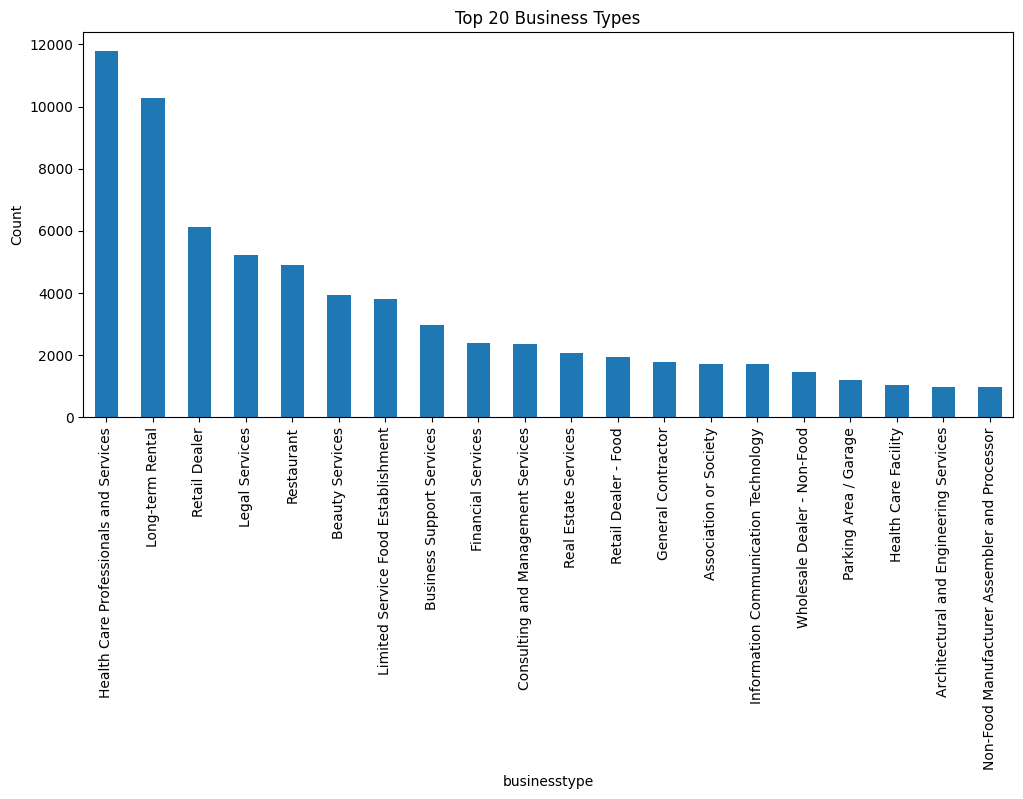

In [ ]:
business_type_count.head(20).plot(kind = "bar", figsize=(12, 5))

plt.title("Top 20 Business Types")
plt.ylabel("Count")
plt.show()

My approach is to keep the most common categories, while putting businesses that are in rare categories into a new category called "other". This way, we can still see the most prevalent business types, and rare categories with very low prevalance are consolodated into one single category. It's likely that we're less interested in the low-prevalance categories too.

In [ ]:
top_categories = business_type_count.head(15).index

issued["businesstype_grouped"] = issued ["businesstype"].where(
    issued["businesstype"].isin(top_categories),
    "Other"
)

In [ ]:
issued["businesstype_grouped"].value_counts()

,count
businesstype_grouped,
Other,22863
Health Care Professionals and Services,11803
Long-term Rental,10266
Retail Dealer,6137
Legal Services,5211
Restaurant,4914
Beauty Services,3940
Limited Service Food Establishment,3814
Business Support Services,2961


# **Combining Business Type and Business Subtype**

Some business types have a subtype, but not all. For the ones that do, I can combine them. This gives more detailed information about the businesses.

In [ ]:
issued["industry"] = issued.apply(
    lambda row:
    f"{row["businesstype"]} - {row["businesssubtype"]}"
    if pd.notna(row["businesssubtype"])
    else row["businesstype"],
  axis=1
)

# **Reducing Sample Size**

There are 26 columns of data. Not all of them are important and will make responsiveness in Streamlit difficult later. I'll be keeping only the columns I will actually use.

In [ ]:
keep = [
    "businessname",
    "businesstype",
    "businesstype_grouped",
    "industry",
    "status",
    "numberofemployees",
    "feepaid",
    "localarea",
    "postalcode",
    "geometry"
]

issued = issued[keep]

In [ ]:
issued.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 85872 entries, 1 to 203950
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   businessname          85869 non-null  object  
 1   businesstype          85872 non-null  object  
 2   businesstype_grouped  85872 non-null  object  
 3   industry              85872 non-null  object  
 4   status                85872 non-null  object  
 5   numberofemployees     85872 non-null  float64 
 6   feepaid               59392 non-null  float64 
 7   localarea             85872 non-null  object  
 8   postalcode            85218 non-null  object  
 9   geometry              85872 non-null  geometry
dtypes: float64(2), geometry(1), object(7)
memory usage: 7.2+ MB


In [ ]:
issued.head()

,businessname,businesstype,businesstype_grouped,industry,status,numberofemployees,feepaid,localarea,postalcode,geometry
1,(Tony Haughian),Long-term Rental,Long-term Rental,Long-term Rental,Issued,0.0,226.0,Mount Pleasant,V5T2N4,POINT (-123.08816 49.25774)
2,(Tony Haughian),Long-term Rental,Long-term Rental,Long-term Rental,Issued,0.0,275.0,Mount Pleasant,None,POINT (-123.08956 49.25805)
3,Simone Deborah Avram (Simone Avram),Long-term Rental,Long-term Rental,Long-term Rental,Issued,0.0,188.0,Riley Park,V5V 2C6,POINT (-123.09646 49.2489)
4,(William Squibb),Long-term Rental,Long-term Rental,Long-term Rental,Issued,0.0,437.0,Grandview-Woodland,V5T 3Z3,POINT (-123.06615 49.27546)
5,(Daniel Dittrich),Long-term Rental,Long-term Rental,Long-term Rental,Issued,0.0,282.0,Grandview-Woodland,V5L 1Y5,POINT (-123.05958 49.27937)


In [ ]:
issued.describe()

,numberofemployees,feepaid
count,85872.000000,59392.000000
mean,17.983324,663.150780
std,102.313693,1518.845538
min,0.000000,2.000000
25%,1.000000,265.000000
50%,3.000000,277.000000
75%,9.000000,481.250000
max,5876.000000,63722.000000


# **Location Only Clustering**

### Latitude and Longitude

In [ ]:
issued["longitude"] = issued.geometry.x
issued["latitude"] = issued.geometry.y

X = issued[["longitude", "latitude"]]

The geometry column contains points with an x and a y. X will store coordinates like this: (x, y).

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Latitude and longitude need to be scaled because they have different ranges. Standardizing means both x and y can have equal impact.

### Elbow Method

In [ ]:
inertia = []

K = range(1, 15)

for k in K:
  model = KMeans(
      n_clusters = k,
      random_state = 42,
      n_init = 10
  )

  model.fit(X_scaled)
  inertia.append(model.inertia_)

I need to choose the number of clusters for KMeans, so this lets us test different values.

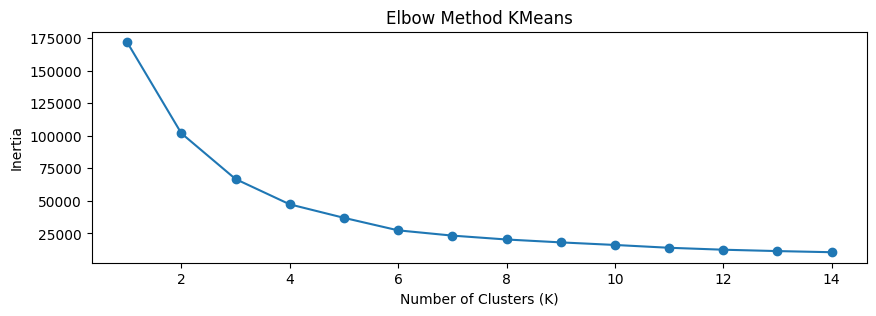

In [ ]:
plt.figure(figsize=(10,3))

plt.plot(K, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method KMeans")

plt.show()

I *think* the elbow is at 6... I can't really tell if it should be 4 or 6 but I think I will stick with 6 because that's where it really flattens out.

### Fitting

In [ ]:
kmeans = KMeans(
    n_clusters = 6,
    random_state = 42,
    n_init = 10
)

issued["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

The number of clusters is replaced with what the visualization above revealed.

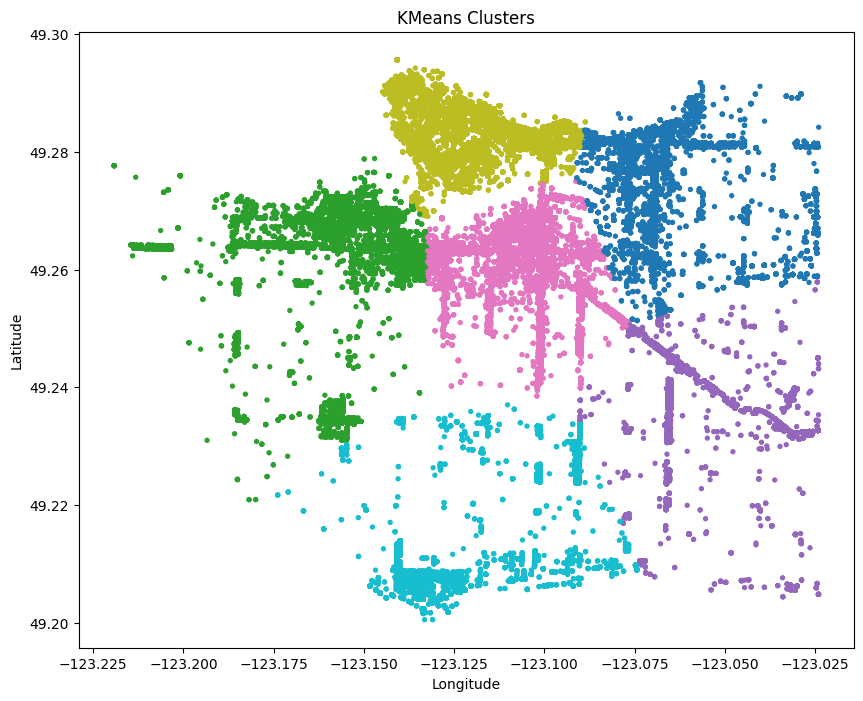

In [ ]:
plt.figure(figsize = (10, 8))

plt.scatter(
    issued["longitude"],
    issued["latitude"],
    c = issued["kmeans_cluster"],
    cmap = "tab10",
    s = 8
)

plt.title("KMeans Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

Each colour represents a cluster, and businesses that are in the same KMeans cluster are the same colour.

### DBSCAN

In [ ]:
dbscan = DBSCAN(
    eps = 0.8,
    min_samples = 20
)

issued["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

NameError: name 'DBSCAN' is not defined

I don't need to choose k for DBSCAN, instead eps and min_samples. This takes some trial and error.

Eps is how close businesses must be to be considered neighbours. Smaller values mean more clusters, and larger values mean less clusters.

Min_samples means the minimum nearby businesses required to create a cluster. Larger values mean fewer clusters.

In [ ]:
plt.figure(figsize = (10, 8))

plt.scatter(
    issued["longitude"],
    issued["latitude"],
    c = issued["dbscan_cluster"],
    cmap = "tab20",
    s = 8
)

plt.title("DBSCAN Clusters")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()